In [3]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import seaborn as sns


Lab 5 - Klasteryzacja


1. Pobieranie danych

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df_raw = pd.read_excel(url)

2. Czyszczenie domenowe

In [5]:
df = df_raw.dropna(subset=['CustomerID']) # CustomerId nie jest cechą
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)] # Quantity oraz UnitPrice < 0 są nie poprawnymi danymi

3. Dodanie kolumny z TotalSum

In [6]:
df['TotalSum'] = df['Quantity'] * df['UnitPrice']

4. Obliczanie RFM

In [7]:
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

customers = df.groupby(['CustomerID']).agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalSum': 'sum'
}).reset_index()

customers.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'MonetaryValue'
}, inplace=True)

5. Ustawienie CustomerId jako index

In [8]:
customers.set_index('CustomerID', inplace=True)

print(customers.head())
print(f"\nLiczba unikalnych klientów do klasteryzacji: {customers.shape[0]}")

            Recency  Frequency  MonetaryValue
CustomerID                                   
12346.0         326          1       77183.60
12347.0           2        182        4310.00
12348.0          75         31        1797.24
12349.0          19         73        1757.55
12350.0         310         17         334.40

Liczba unikalnych klientów do klasteryzacji: 4338


6. Skalowanie danych

In [9]:
customers_log = np.log(customers)
scaler = StandardScaler()
customers_scaled = scaler.fit_transform(customers_log)
customers_scaled = pd.DataFrame(customers_scaled, index=customers.index, columns=customers.columns)

7. Szukanie optymalnego K

/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: 

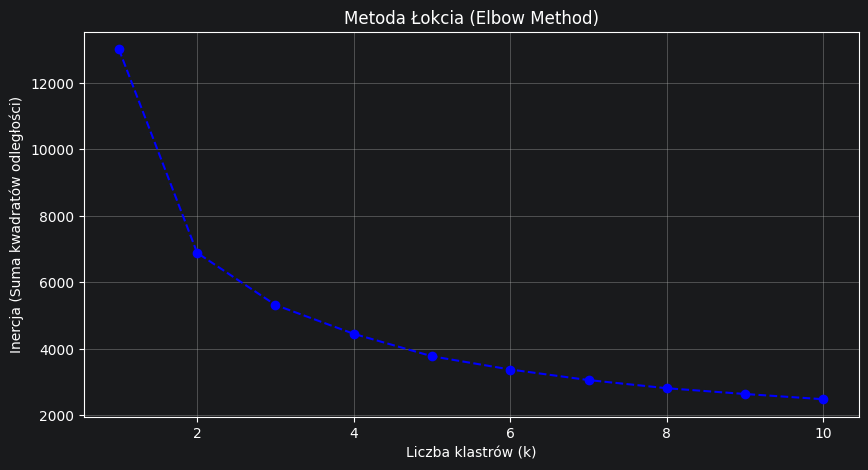

In [10]:
sse = {} # SSE = Sum of Squared Errors (Inercja)
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=1, n_init=10)
    kmeans.fit(customers_scaled)
    sse[k] = kmeans.inertia_

plt.figure(figsize=(10, 5))
plt.plot(list(sse.keys()), list(sse.values()), marker='o', linestyle='--', color='b')
plt.title('Metoda Łokcia (Elbow Method)')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Inercja (Suma kwadratów odległości)')
plt.grid(True)
plt.show()


8. Trenowanie modelu docelowego dla K = 3

In [11]:
kmeans = KMeans(n_clusters=3, random_state=1, n_init=10)
kmeans.fit(customers_scaled)
customers['Cluster'] = kmeans.labels_

/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: 

9. Ewaluacja

In [12]:
sil_score = silhouette_score(customers_scaled, kmeans.labels_)
ch_score = calinski_harabasz_score(customers_scaled, kmeans.labels_)
db_score = davies_bouldin_score(customers_scaled, kmeans.labels_)

print(f"Silhouette Score: {sil_score:.3f}")
print(f"Calinski-Harabasz: {ch_score:.1f}")
print(f"Davies-Bouldin: {db_score:.3f}")

Silhouette Score: 0.303
Calinski-Harabasz: 3141.4
Davies-Bouldin: 1.098


/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mateusz/PyCharmMi

10. Interpretacja wyników

In [13]:
cluster_avg = customers.groupby('Cluster').mean().round(1)
cluster_sizes = customers.groupby('Cluster').size()
cluster_avg['Liczba_klientow'] = cluster_sizes

print(cluster_avg)

         Recency  Frequency  MonetaryValue  Liczba_klientow
Cluster                                                    
0           13.0      262.9         6553.2              958
1          170.5       14.9          294.5             1528
2           69.3       66.5         1179.0             1852


11. Wizualizacja w 2D

/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


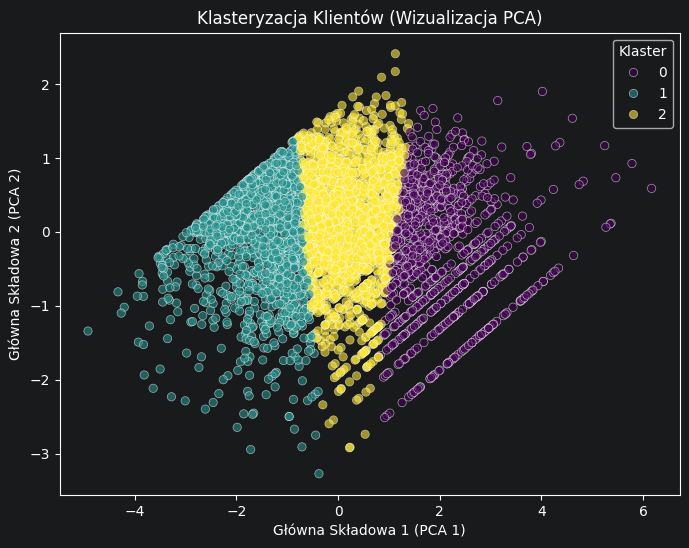

In [14]:
pca = PCA(n_components=2)
customers_pca = pca.fit_transform(customers_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=customers_pca[:, 0], y=customers_pca[:, 1], hue=customers['Cluster'], palette='viridis', alpha=0.6)
plt.title('Klasteryzacja Klientów (Wizualizacja PCA)')
plt.xlabel('Główna Składowa 1 (PCA 1)')
plt.ylabel('Główna Składowa 2 (PCA 2)')
plt.legend(title='Klaster')
plt.show()

Wnioski:
- są 3 grupy klient (tak wyraliśmy na podstawie współczynnika K)
- grupy klientów to:
  - Klienci utraceni (Data ostatniego zakupu jest najwyższa  - Recency)
  - Klienci stali (Mają najwyższą częstość kupoania - Frequency i niski czas od ostatniego zakupu - Receny)
  - Klienci zwykli